# Exploratory Data Analysis (EDA) - Mutual Fund Analysis

This notebook contains exploratory data analysis of the Mutual Fund dataset provided by Bluestock Fintech.

### Objectives
- Analyze NAV trends
- Study AUM growth
- Analyze SIP inflows
- Explore category inflows
- Study investor demographics
- Analyze geographic distribution
- Study folio growth
- Compute NAV correlation
- Analyze sector allocation
- Document key insights

In [101]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [102]:
fund_master = pd.read_csv("/content/01_fund_master_processed.csv")
nav_history = pd.read_csv("/content/02_nav_history_processed.csv")
aum = pd.read_csv("/content/03_aum_by_fund_house_processed.csv")
sip = pd.read_csv("/content/04_monthly_sip_inflows_processed.csv")
category = pd.read_csv("/content/05_category_inflows_processed.csv")
folio = pd.read_csv("/content/06_industry_folio_count_processed.csv")
performance = pd.read_csv("/content/07_scheme_performance_processed.csv")
investor = pd.read_csv("/content/08_investor_transactions_processed.csv")
holdings = pd.read_csv("/content/09_portfolio_holdings_processed.csv")
benchmark = pd.read_csv("/content/10_benchmark_indices_processed.csv")

In [103]:
nav = nav_history.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav['date'] = pd.to_datetime(nav['date'])



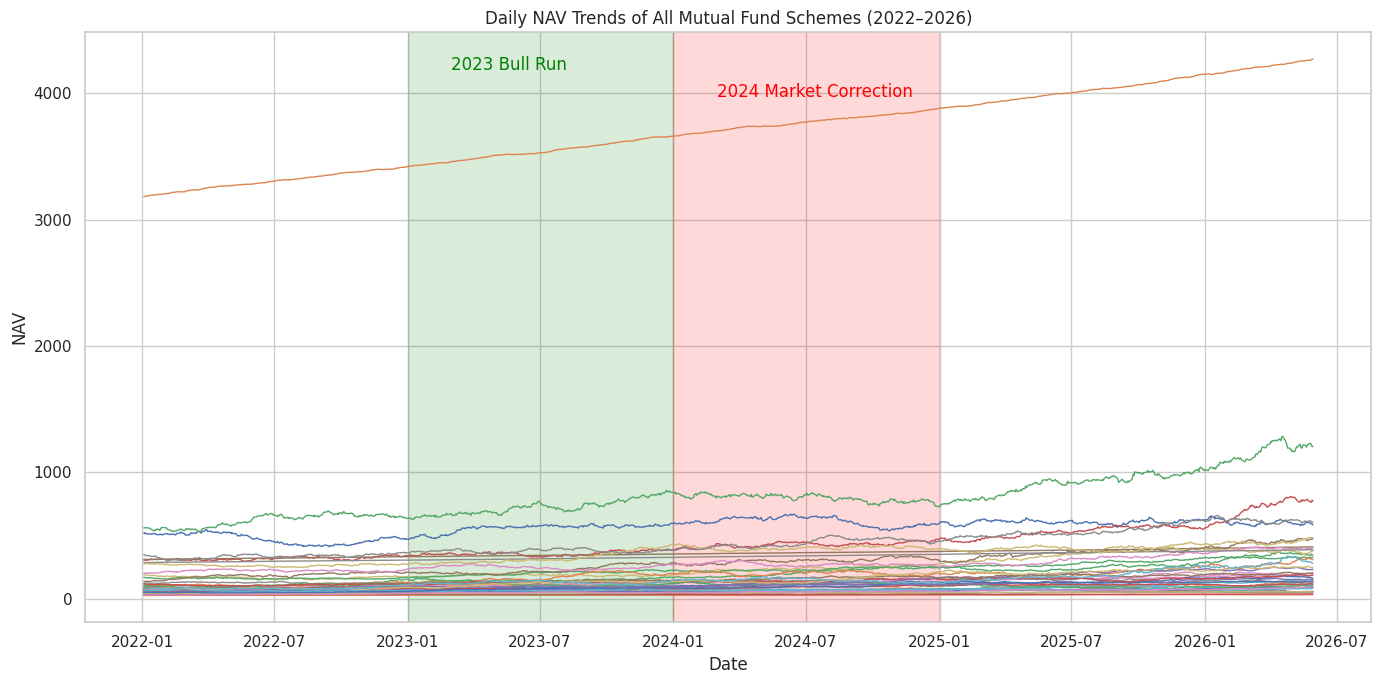

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for scheme in nav["scheme_name"].unique():
    temp = nav[nav["scheme_name"] == scheme]
    plt.plot(temp["date"], temp["nav"], linewidth=1)

# Highlight periods
plt.axvspan(pd.to_datetime("2023-01-01"),
            pd.to_datetime("2023-12-31"),
            color="green", alpha=0.15)

plt.axvspan(pd.to_datetime("2024-01-01"),
            pd.to_datetime("2024-12-31"),
            color="red", alpha=0.15)

plt.text(pd.to_datetime("2023-03-01"),
         nav["nav"].max()*0.98,
         "2023 Bull Run",
         color="green")

plt.text(pd.to_datetime("2024-03-01"),
         nav["nav"].max()*0.93,
         "2024 Market Correction",
         color="red")

plt.title("Daily NAV Trends of All Mutual Fund Schemes (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.tight_layout()
plt.savefig("01_NAV_Trend.png", dpi=300)
plt.show()

## Finding 1

The Net Asset Value (NAV) of most mutual fund schemes showed an overall upward trend from 2022 to 2025, despite temporary market corrections.

**Supporting Chart:** Figure 1 – NAV Trend

In [105]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

yearly_aum = (
    aum.groupby(["year", "fund_house"], as_index=False)["aum_lakh_crore"]
    .max()
)



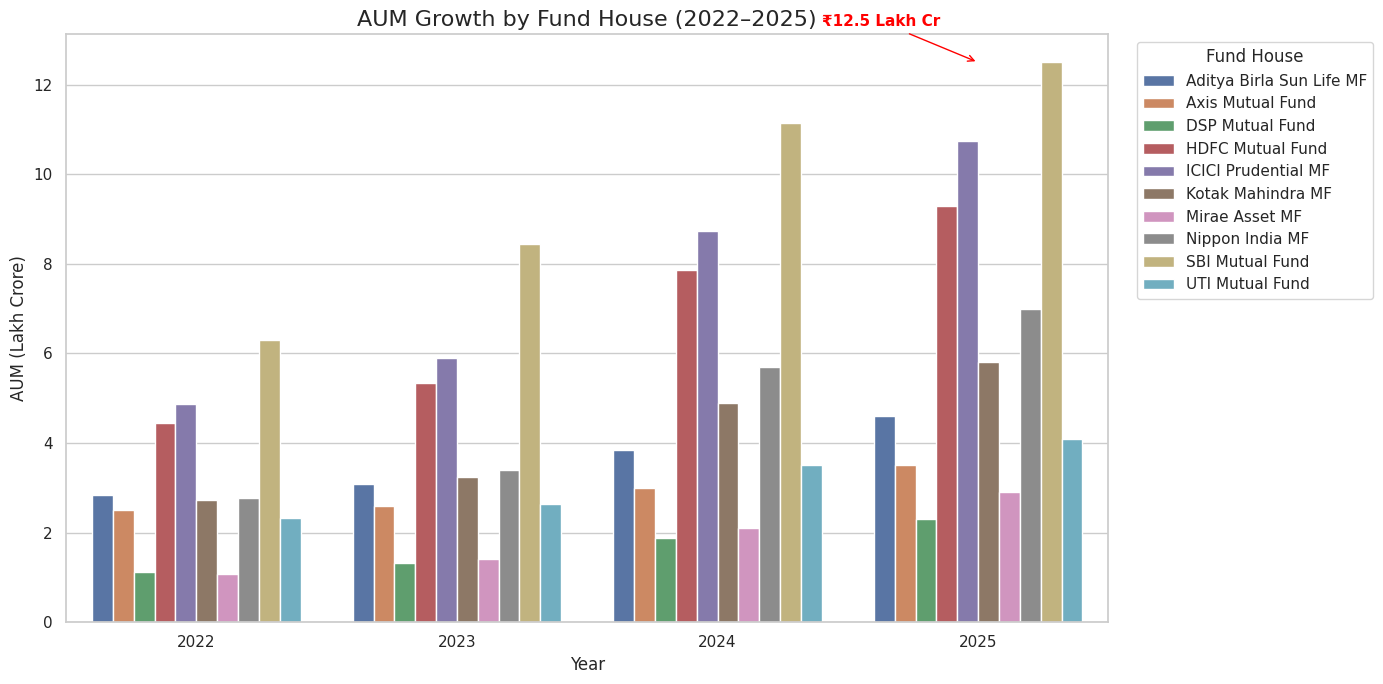

In [106]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

# Highlight SBI 2025
sbi_2025 = yearly_aum[
    (yearly_aum["fund_house"]=="SBI Mutual Fund") &
    (yearly_aum["year"]==2025)
]

if not sbi_2025.empty:
    value = sbi_2025["aum_lakh_crore"].values[0]
    plt.annotate(
        "₹12.5 Lakh Cr",
        xy=(3, value),          # 2025 is the 4th x-category (index 3)
        xytext=(2.4, value+0.8),
        arrowprops=dict(arrowstyle="->", color="red"),
        fontsize=11,
        color="red",
        weight="bold"
    )

plt.tight_layout()
plt.show()

## Finding 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), indicating strong investor confidence.

**Supporting Chart:** Figure 2 – AUM Growth Bar Chart

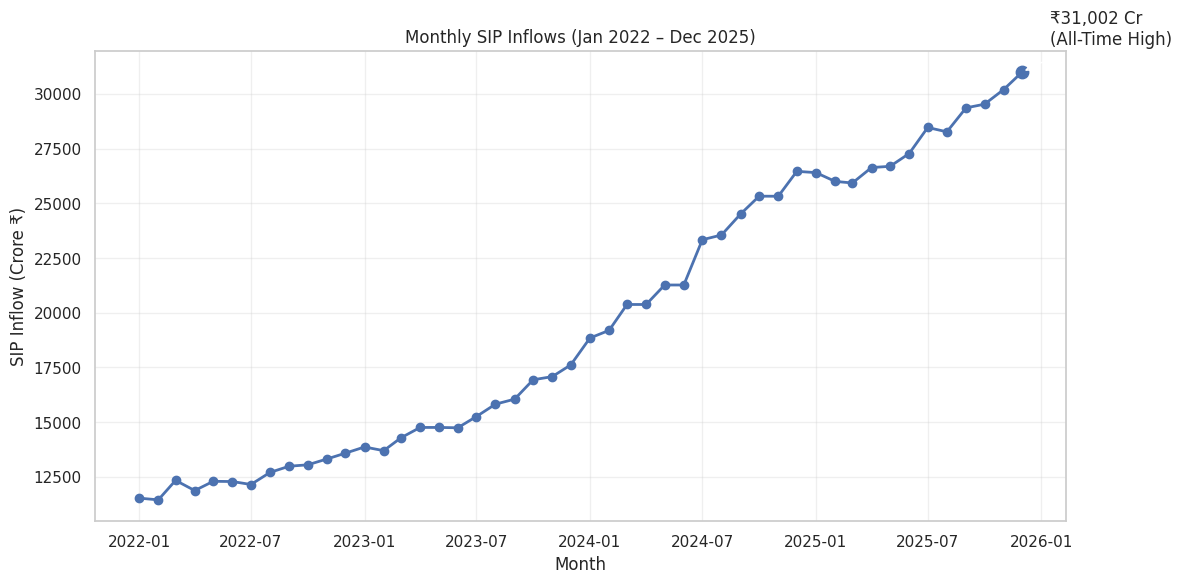

In [129]:
import matplotlib.pyplot as plt

sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    linewidth=2,
    marker="o"
)

# Highlight highest point
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.scatter(
    max_row["month"],
    max_row["sip_inflow_crore"],
    s=80
)

plt.annotate(
    f"₹{max_row['sip_inflow_crore']:,} Cr\n(All-Time High)",
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore ₹)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("03_SIP_Trend.png", dpi=300)
plt.show()

## Finding 3

Monthly SIP inflows increased steadily throughout the study period, reflecting growing retail participation in mutual funds.

**Supporting Chart:** Figure 3 – SIP Trend


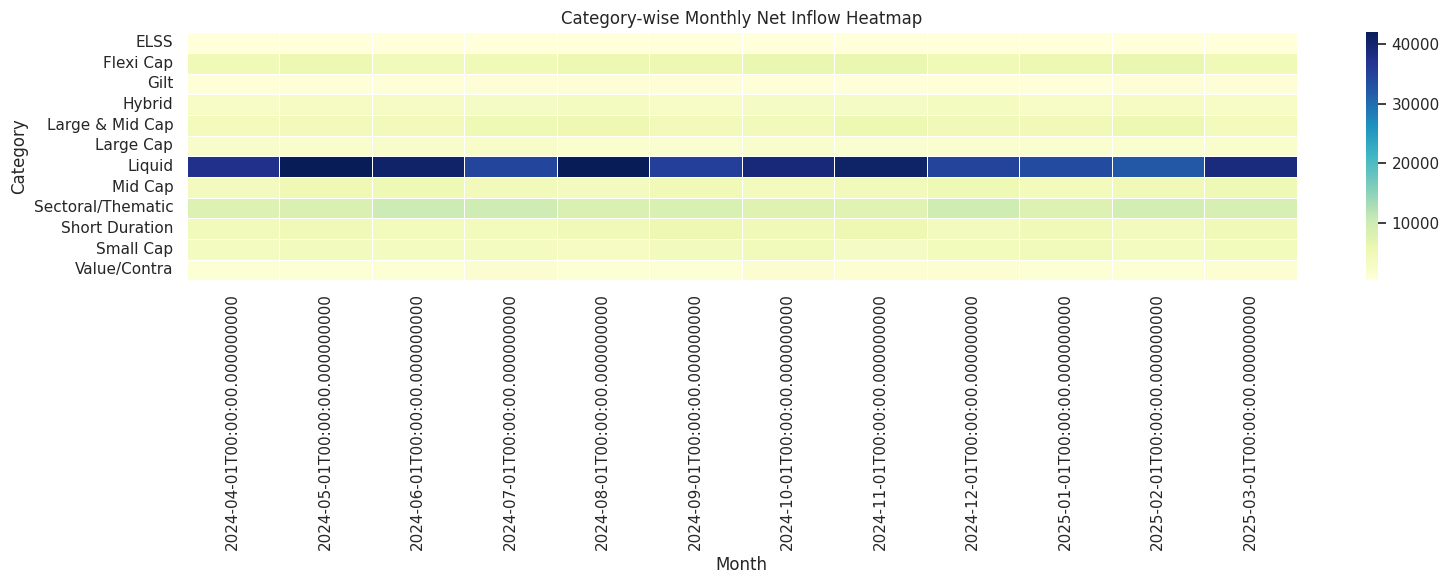

In [108]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("04_Category_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 4

Net inflows varied across mutual fund categories, with several categories experiencing stronger inflows during different periods.

**Supporting Chart:** Figure 4 – Category Heatmap

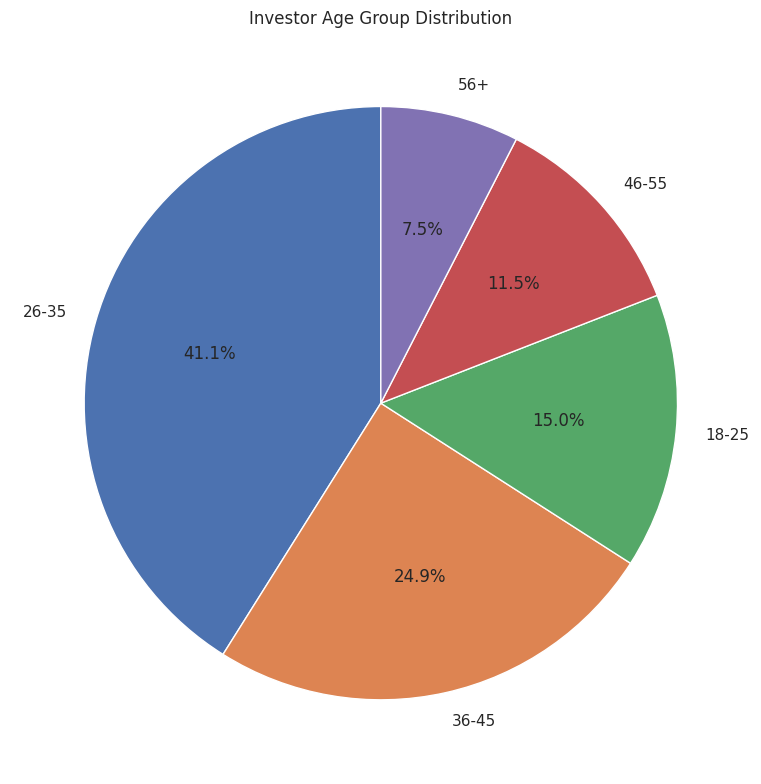

In [109]:
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()
plt.savefig("05_Age_Group_Pie.png", dpi=300, bbox_inches="tight")
plt.show()

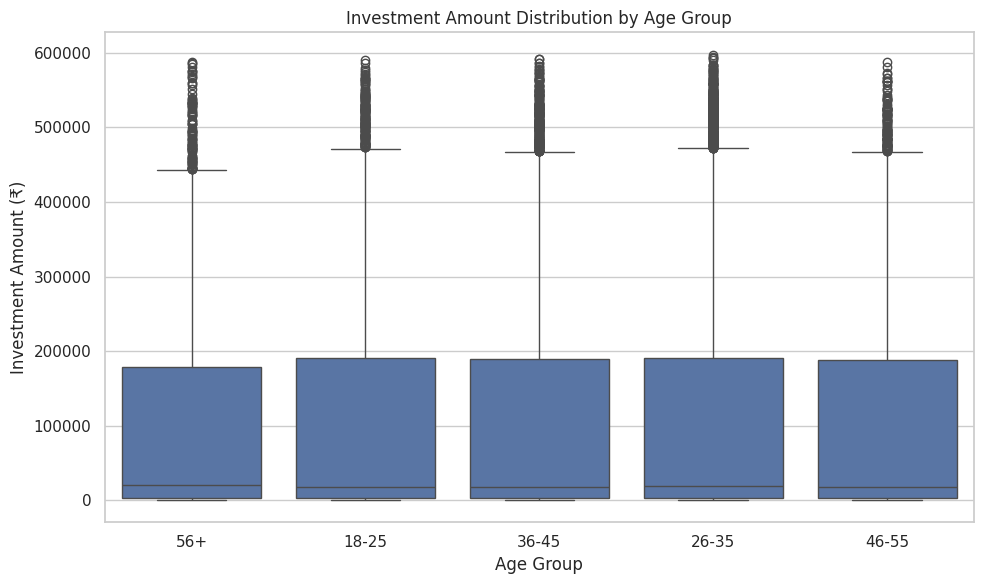

In [110]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()
plt.savefig("06_Age_Group_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 5

Most investors belong to a limited number of age groups, indicating concentration of investments among specific demographics.

**Supporting Charts:** Figure 5 – Age Group Pie Chart, Figure 6 – Age Group Boxplot

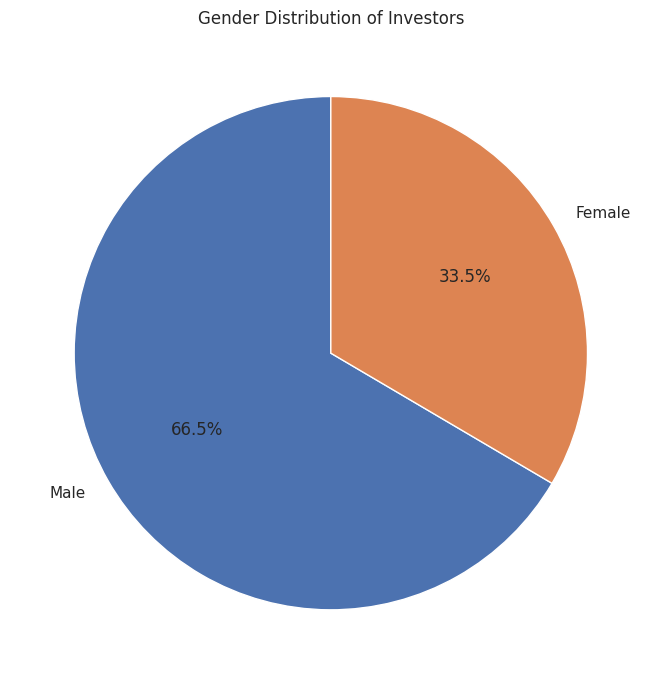

In [111]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.tight_layout()
plt.savefig("07_Gender_Split.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 6

Investor participation differs across genders, highlighting demographic diversity within mutual fund investments.

**Supporting Chart:** Figure 7 – Gender Split

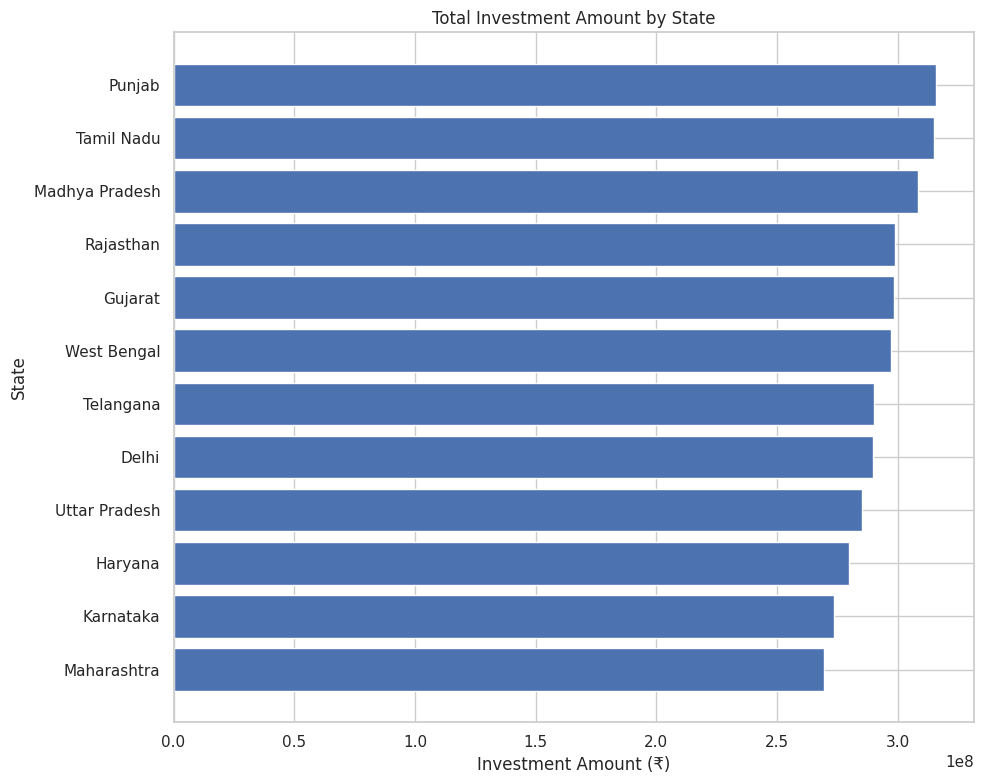

In [112]:
state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,8))

plt.barh(
    state_data.index,
    state_data.values
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("08_State_Investment.png", dpi=300, bbox_inches="tight")
plt.show()

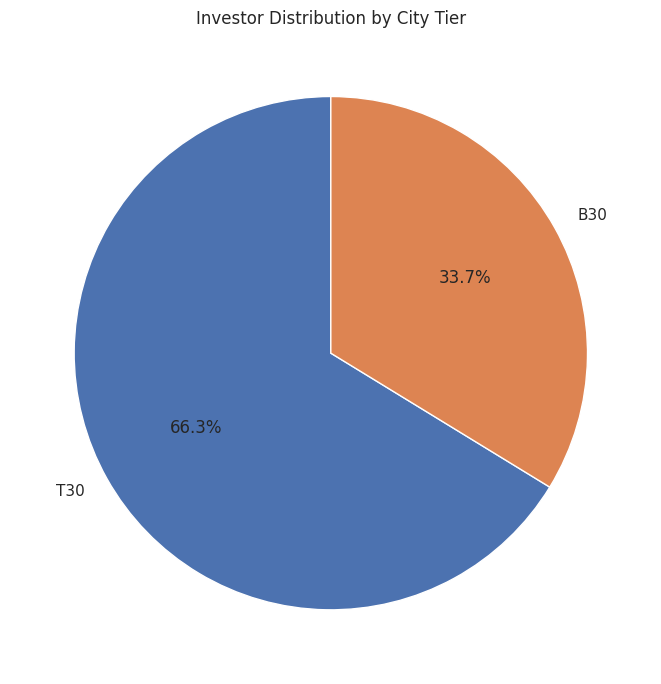

In [113]:
tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.tight_layout()
plt.savefig("09_City_Tier_Pie.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 7

Investments are concentrated in a few major states and Tier-1 cities, indicating geographical concentration of mutual fund participation.

**Supporting Charts:** Figure 8 – State Investment, Figure 9 – City Tier Distribution

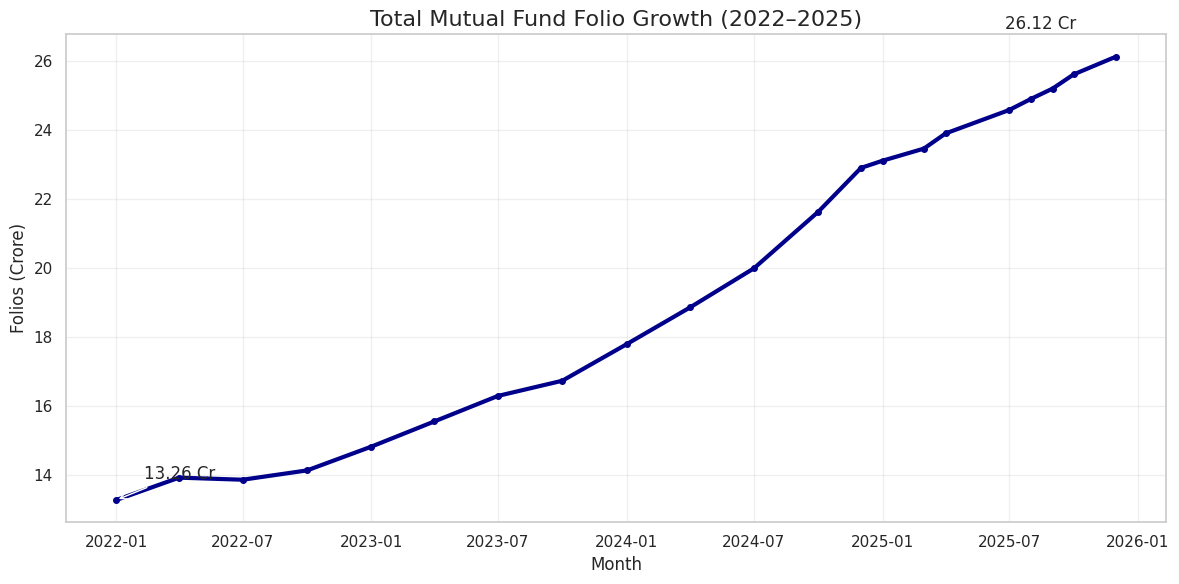

In [114]:
# Convert month column to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    color="darkblue",
    linewidth=3,
    marker="o",
    markersize=4
)

plt.title("Total Mutual Fund Folio Growth (2022–2025)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True, alpha=0.3)

# Mark first and last values
plt.annotate(
    f'{folio["total_folios_crore"].iloc[0]:.2f} Cr',
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(20,15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f'{folio["total_folios_crore"].iloc[-1]:.2f} Cr',
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(-80,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig("10_Folio_Growth.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 8

The number of mutual fund folios has grown consistently over time, indicating increasing investor adoption.

**Supporting Chart:** Figure 10 – Folio Growth

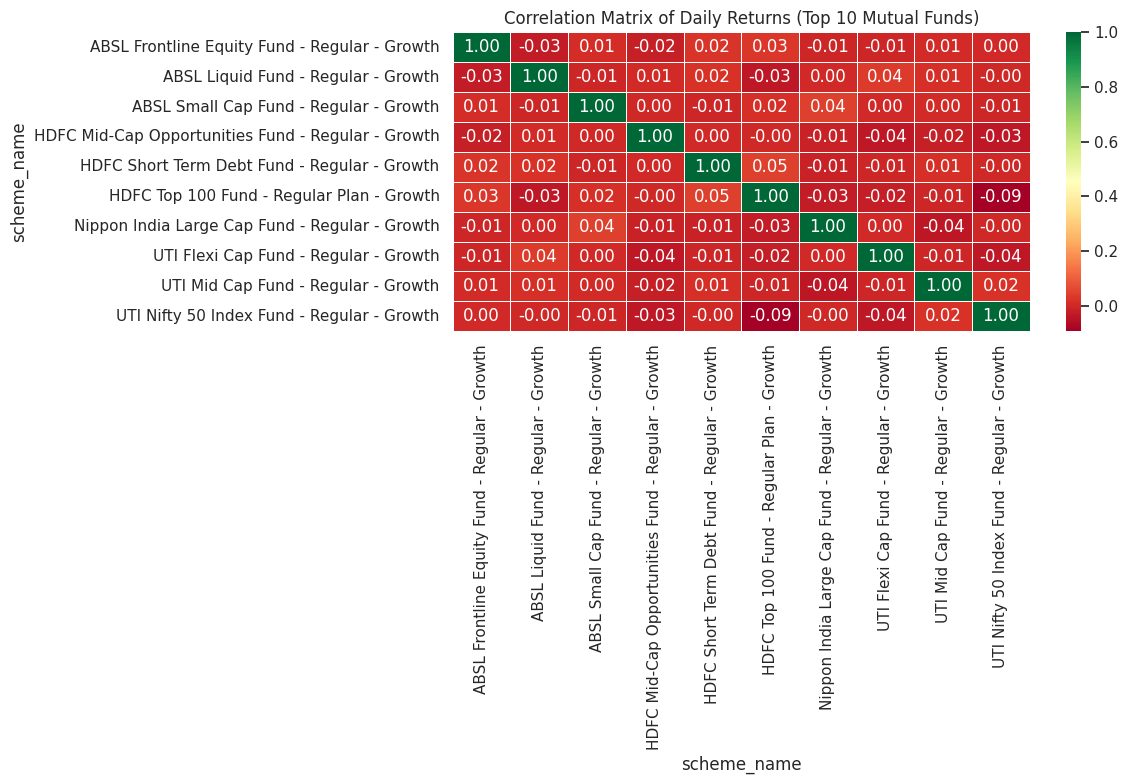

In [115]:
# Select 10 mutual fund schemes
top10_funds = nav["scheme_name"].drop_duplicates().head(10)

nav_top10 = nav[nav["scheme_name"].isin(top10_funds)]

# Pivot table
nav_pivot = nav_top10.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Calculate daily returns
daily_returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = daily_returns.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily Returns (Top 10 Mutual Funds)")
plt.tight_layout()


plt.savefig("11_NAV_Return_Correlation.png", dpi=300, bbox_inches="tight")
plt.show()

### Finding 9

The daily returns of the selected mutual fund schemes exhibit varying degrees of correlation. Funds with similar investment objectives show stronger positive relationships, while diversified categories display comparatively lower correlations.

**Supporting Chart:** Figure 11 – NAV Return Correlation Matrix

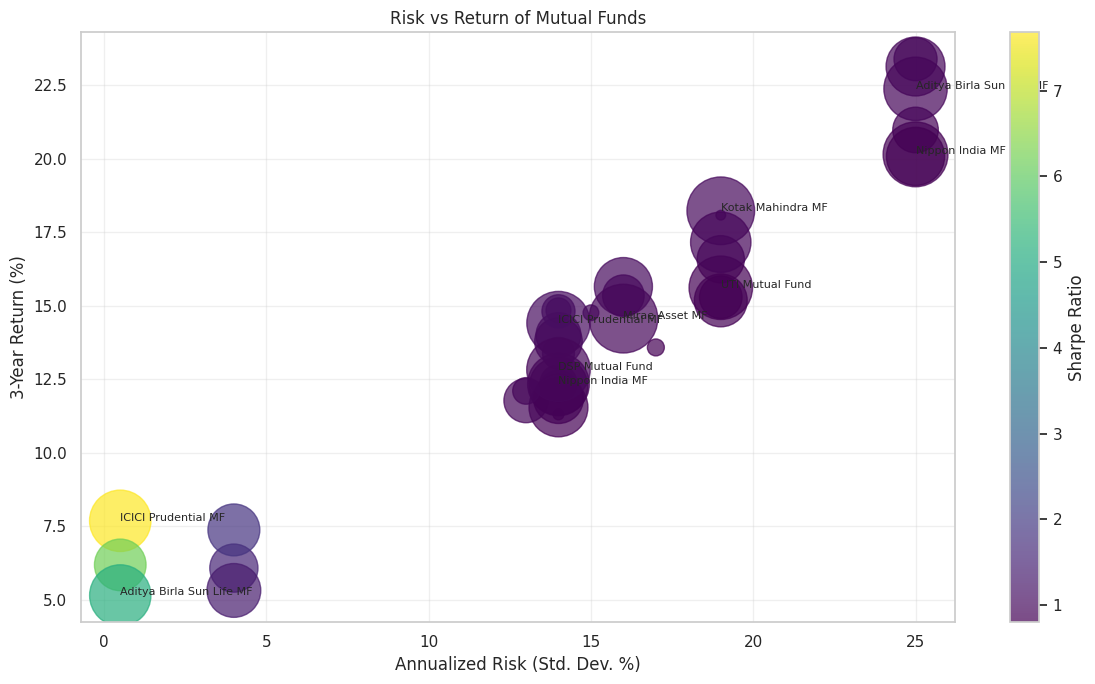

In [116]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"],
    s=performance["aum_crore"]/20,
    c=performance["sharpe_ratio"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.xlabel("Annualized Risk (Std. Dev. %)")
plt.ylabel("3-Year Return (%)")
plt.title("Risk vs Return of Mutual Funds")

# Label top 10 funds by AUM
top = performance.nlargest(10, "aum_crore")

for _, row in top.iterrows():
    plt.text(
        row["std_dev_ann_pct"],
        row["return_3yr_pct"],
        row["fund_house"],
        fontsize=8
    )

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("12_Risk_Return_Scatter.png", dpi=300, bbox_inches="tight")
plt.show()

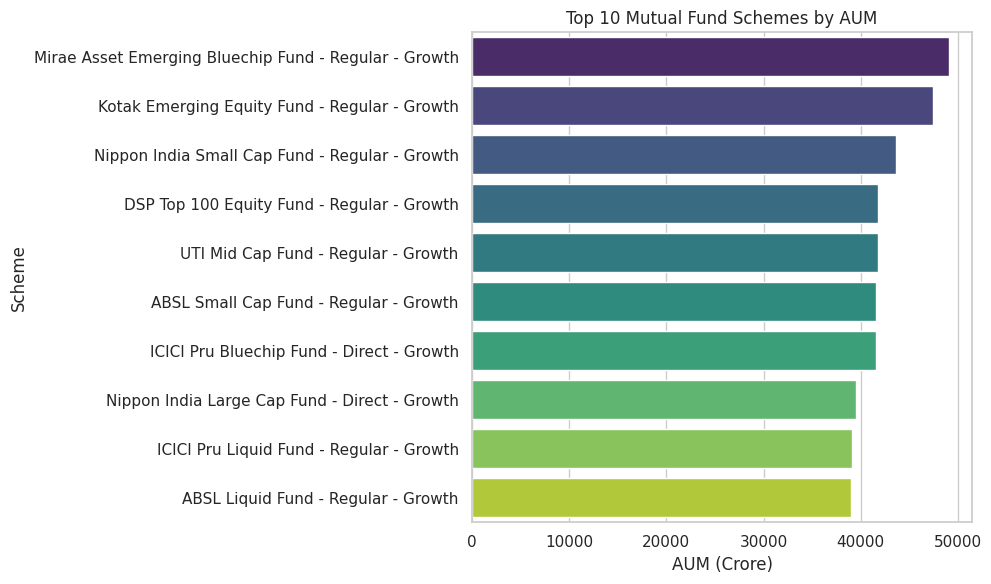

In [117]:
top_aum = (
    performance.sort_values("aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_aum,
    x="aum_crore",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Mutual Fund Schemes by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.savefig("13_Top10_AUM.png", dpi=300, bbox_inches="tight")
plt.show()

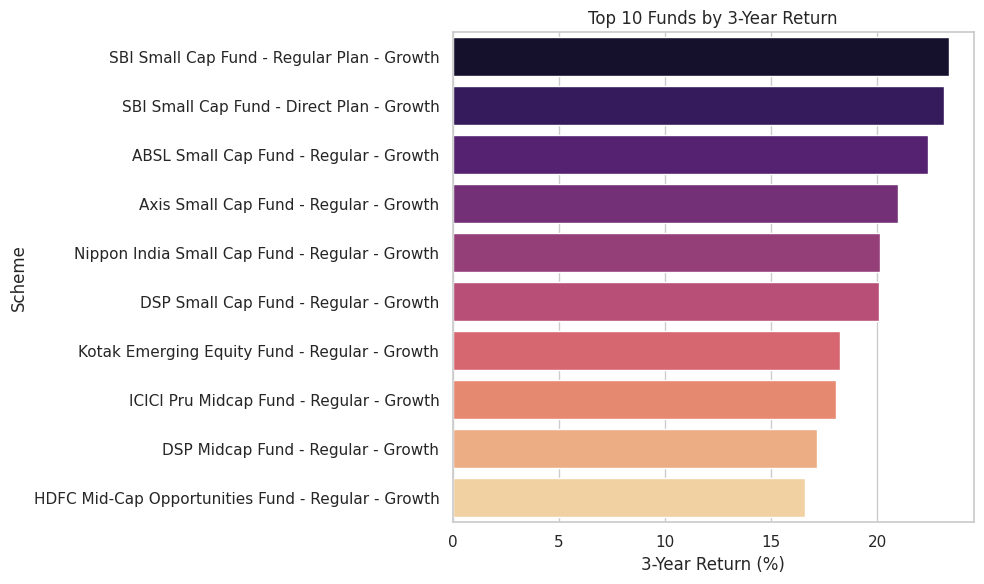

In [118]:
top_return = (
    performance.sort_values("return_3yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_return,
    x="return_3yr_pct",
    y="scheme_name",
    palette="magma"
)

plt.title("Top 10 Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.savefig("14_Top10_Return.png", dpi=300, bbox_inches="tight")
plt.show()

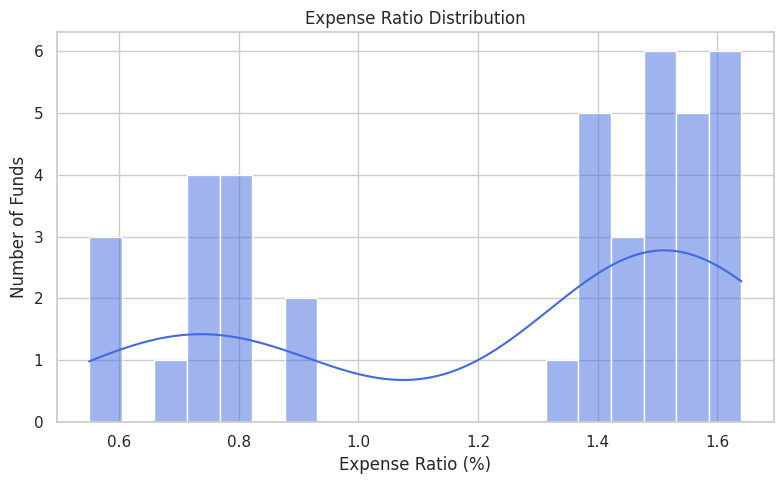

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.savefig("15_Expense_Ratio.png", dpi=300, bbox_inches="tight")
plt.show()

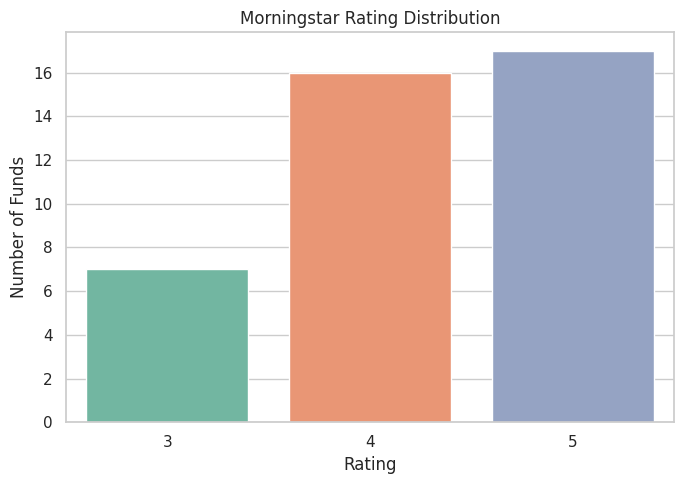

In [120]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=performance,
    x="morningstar_rating",
    palette="Set2"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.savefig("16_Morningstar_Rating.png", dpi=300, bbox_inches="tight")
plt.show()

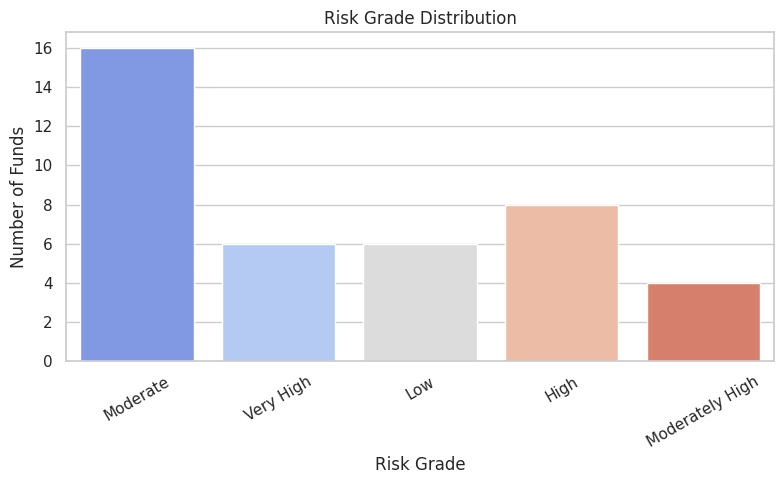

In [121]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade",
    palette="coolwarm"
)

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("17_Risk_Grade.png", dpi=300, bbox_inches="tight")
plt.show()

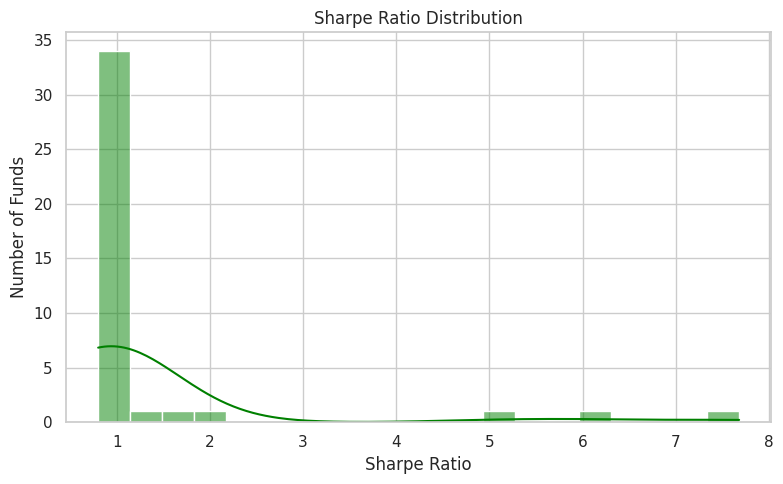

In [122]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["sharpe_ratio"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Sharpe Ratio Distribution")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.savefig("18_Sharpe_Ratio.png", dpi=300, bbox_inches="tight")
plt.show()

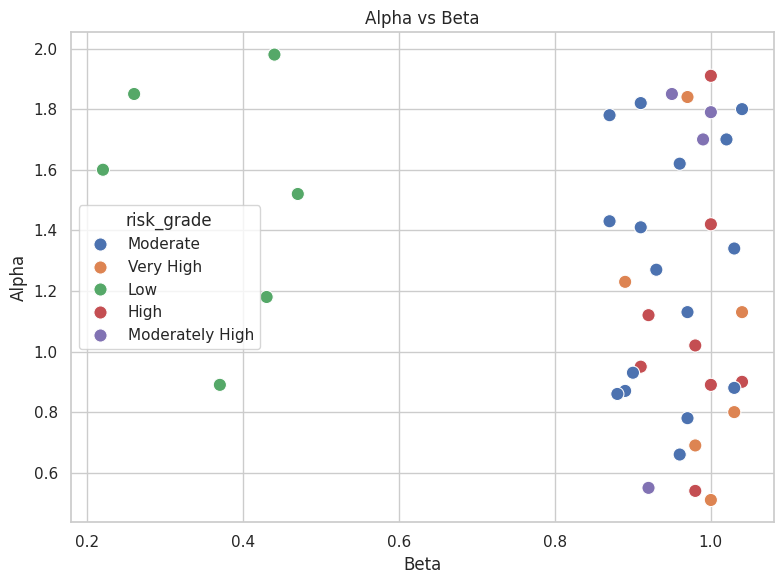

In [123]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha",
    hue="risk_grade",
    s=90
)

plt.title("Alpha vs Beta")
plt.xlabel("Beta")
plt.ylabel("Alpha")

plt.tight_layout()
plt.savefig("19_Alpha_Beta.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 10

Risk-adjusted performance varies across schemes, with higher returns generally associated with higher volatility.

**Supporting Charts:** Figure 12 – Risk vs Return Scatter, Figure 19 – Alpha vs Beta

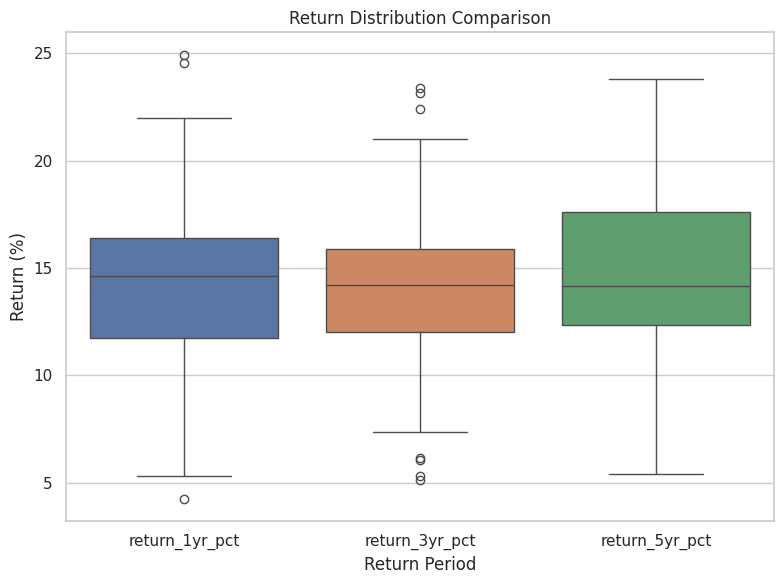

In [124]:
returns = performance[
    ["return_1yr_pct",
     "return_3yr_pct",
     "return_5yr_pct"]
]

plt.figure(figsize=(8,6))

sns.boxplot(data=returns)

plt.title("Return Distribution Comparison")
plt.xlabel("Return Period")
plt.ylabel("Return (%)")

plt.tight_layout()
plt.savefig("20_Return_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Finding 11

Fund performance characteristics such as expense ratio, Sharpe ratio, Morningstar ratings and risk grades exhibit considerable variation across schemes.

**Supporting Charts:** Figures 15–20

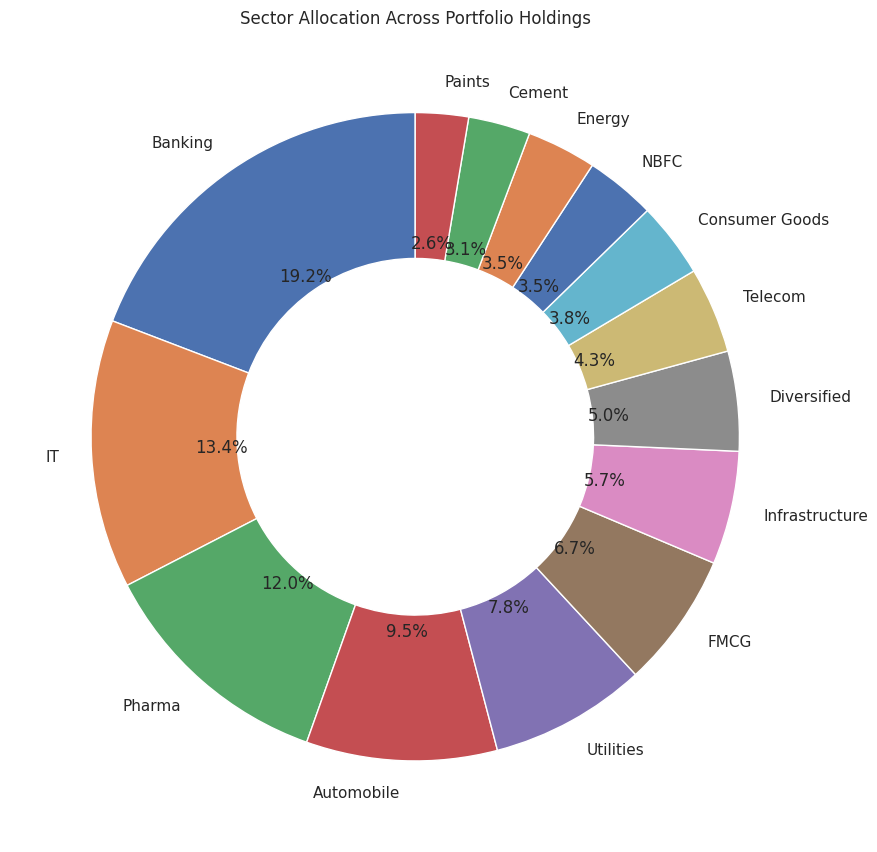

In [125]:
sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

wedges, texts, autotexts = plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.45)
)

plt.title("Sector Allocation Across Portfolio Holdings")

plt.tight_layout()


plt.savefig("21_Sector_Allocation_Donut.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Finding 12

Sector allocation is concentrated in a few major industries, indicating that mutual fund portfolios maintain diversified exposure while allocating larger weights to dominant sectors.

**Supporting Chart:** Figure 21 – Sector Allocation Donut Chart